## Superdense Coding
Superdense coding is a quantum communication protocol that allows two parties, Alice and Bob, to transmit two classical bits of information using only one qubit. This is achieved by utilizing the properties of quantum entanglement.

### The Story:
Imagine Alice wants to send Bob a 2-bit secret code (it can be `00`, `01`, `10`, or `11`). Normally, she would have to send him two physical bits. But in the quantum world, if they share an entangled "telephone line", Alice can compress her 2-bit message into a single qubit, mail that one qubit to Bob, and Bob can unpack it to read both bits!

In [1]:
# imorting the libraries
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
# We need 2 qubits (one for Alice, one for Bob) and 2 classical bits for the final answer
qc = QuantumCircuit(2, 2)

### --- Step 1: Create an Entangled Pair "Telephone Line" ---
First, Alice and Bob need to create an entangled pair of qubits. They can do this by using a quantum gate called the Hadamard gate followed by a CNOT gate. This creates a special state called a Bell state, which is a maximally entangled state.

In [3]:
# Alice and Bob share a Bell Sate

qc.h(0)
qc.cx(0, 1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

### --- Step 2: Alice Encodes Her Message ---

- Let's say Alice wants to send the message `11` to Bob.
- Based on her message, she applies specific gates to her qubit only (Qubit 0):
  - For `00`: Do nothing (Identity)
  - For `01`: Apply the X gate (bit flip)
  - For `10`: Apply the Z gate (phase flip)
  - For `11`: Apply both X and Z gates (bit and phase flip)

In [4]:
message = "11" # Change this to "00", "01", "10", or "11" to test it!

In [5]:
if message == "01":
    qc.x(0)
elif message == "10":
    qc.z(0)
elif message == "11":
    qc.z(0)
    qc.x(0)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

### --- Step 3: Alice "mails" her single qubit to Bob ---
In code, we just move to Bob's decoding step, but in a real-world scenario, Alice would physically send her qubit to Bob.

### --- Step 4: Bob Decodes the Message ---
Bob now has both qubits (his original one and the one Alice sent). He applies a CNOT gate followed by a Hadamard gate to his qubits. This allows him to decode the message and retrieve the original 2-bit message that Alice sent.

In [6]:
qc.cx(0, 1)
qc.h(0)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

### --- Step 5: Bob Reads the Message ---
Bob measures both qubits to reveal Alice's 2-bit secret code. In our example, he would read `11`, which is the message Alice wanted to send.

In [7]:
qc.measure([0, 1], [0, 1])

Superdense Coding Circuit (Sending Message: 11):


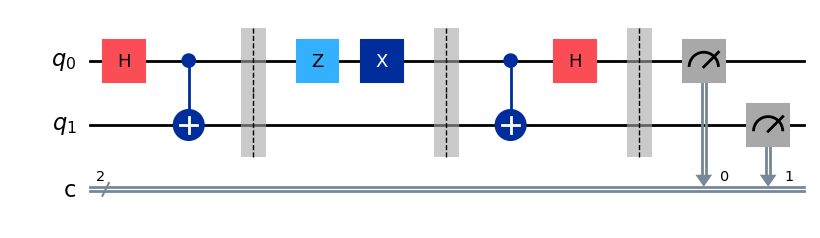

In [8]:
# Draw the circuit
print(f"Superdense Coding Circuit (Sending Message: {message}):")
display(qc.draw("mpl"))

In [9]:
# Run the simulation
simulator = AerSimulator()
job = simulator.run(qc, shots=1000)
result = job.result()

Bob received: {'11': 1000}


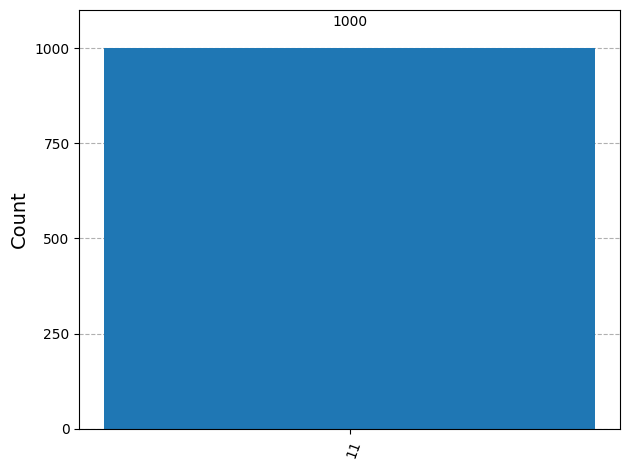

In [10]:
# Show the results
counts = result.get_counts(qc)
print(f"Bob received: {counts}")
display(plot_histogram(counts))